<a href="https://colab.research.google.com/github/renee-m123/Breastcancer_prediction_ml/blob/main/computer%2Bvision.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import torch
from torch import nn

#import torch vision
import torchvision
from torchvision import datasets
from torchvision import transforms
from torchvision.transforms import ToTensor

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt


create tensors


In [ ]:
print(torch.__version__)
print(torchvision.__version__)

2.10.0+cu128
0.25.0+cu128


In [ ]:
#getting the dataset
from torchvision import datasets
train_data = datasets.FashionMNIST(
    root="data",
    train=True,
    download=True,
    transform=ToTensor(),
    target_transform=None
)

test_data = datasets.FashionMNIST(
    root ="data",
    train= False,
    download=True,
    transform=ToTensor(),
    target_transform=None

)

100%|██████████| 26.4M/26.4M [00:01<00:00, 14.3MB/s]
100%|██████████| 29.5k/29.5k [00:00<00:00, 215kB/s]
100%|██████████| 4.42M/4.42M [00:01<00:00, 4.03MB/s]
100%|██████████| 5.15k/5.15k [00:00<00:00, 27.9MB/s]


In [ ]:
len(train_data),len(test_data)

(60000, 10000)

In [ ]:
image, label = train_data[0]
image, label

(tensor([[[0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
           0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
           0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
           0.0000, 0.0000, 0.0000, 0.0000],
          [0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
           0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
           0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
           0.0000, 0.0000, 0.0000, 0.0000],
          [0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
           0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
           0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
           0.0000, 0.0000, 0.0000, 0.0000],
          [0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
           0.0000, 0.0000, 0.0000, 0.0000, 0.0039, 0.0000, 0.0000, 0.0510,
           0.2863, 0.0000, 0.0000, 0.0039, 

In [ ]:
class_names = train_data.classes
class_names

['T-shirt/top',
 'Trouser',
 'Pullover',
 'Dress',
 'Coat',
 'Sandal',
 'Shirt',
 'Sneaker',
 'Bag',
 'Ankle boot']

In [ ]:
class_to_idx = train_data.class_to_idx
class_to_idx

{'T-shirt/top': 0,
 'Trouser': 1,
 'Pullover': 2,
 'Dress': 3,
 'Coat': 4,
 'Sandal': 5,
 'Shirt': 6,
 'Sneaker': 7,
 'Bag': 8,
 'Ankle boot': 9}

image shape: torch.Size([1, 28, 28]), label: 9


(np.float64(-0.5), np.float64(27.5), np.float64(27.5), np.float64(-0.5))

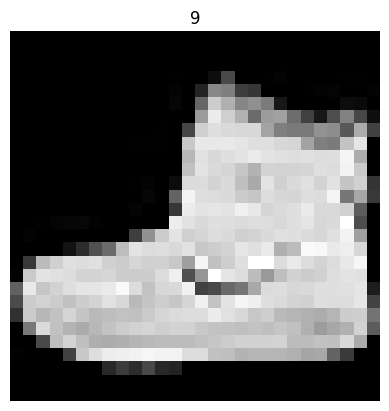

In [ ]:
import matplotlib.pyplot as plt
image, label = train_data[0]
print(f"image shape: {image.shape}, label: {label}")
plt.imshow(image.squeeze(), cmap = "gray")
plt.title(label)
plt.axis(False)

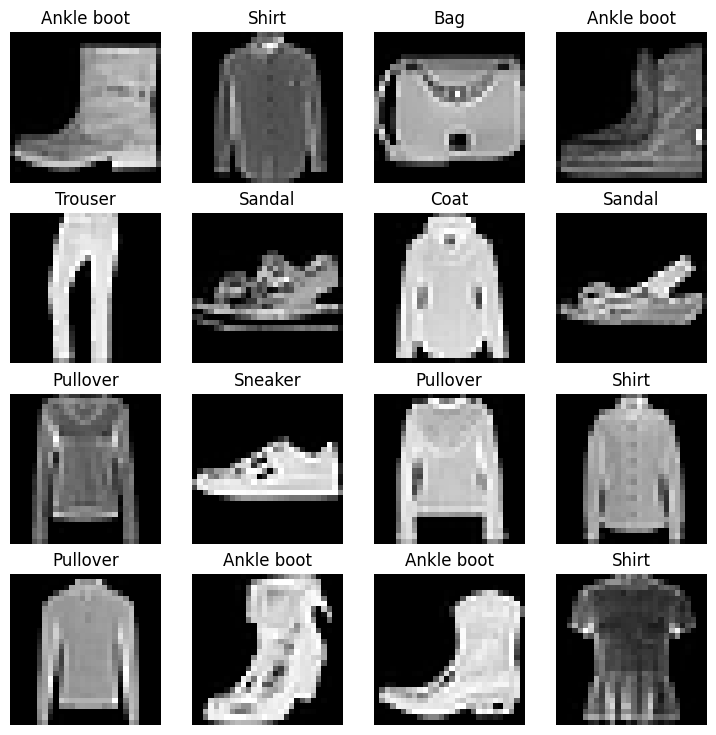

In [ ]:
torch.manual_seed(42)
fig= plt.figure(figsize= (9,9))
rows, cols = 4,4
for i in range(1, rows*cols +1):
  random_idx = torch.randint(0, len(train_data), size = [1]).item()
  image, label = train_data[random_idx]
  fig.add_subplot(rows, cols, i)
  plt.imshow(image.squeeze(), cmap = "gray")
  plt.title(class_names[label])
  plt.axis(False)



In [ ]:
#prepare dataloader
#turns datasets into python iterable(bactches/mini batches)
from torch.utils.data import DataLoader
b_size = 32
 #turns data to batches
train_dataloader= DataLoader(
    dataset=train_data,
    shuffle= True,
    batch_size = b_size)
test_dataloader = DataLoader(dataset = test_data,
                             batch_size = b_size,
                             shuffle= False)

test_dataloader, train_dataloader


(<torch.utils.data.dataloader.DataLoader at 0x7a80fbf10cb0>,
 <torch.utils.data.dataloader.DataLoader at 0x7a80fbfc2300>)

In [ ]:
train_feature_batch, train_labels_batch = next(iter(train_dataloader))
train_feature_batch.shape, train_feature_batch.shape

(torch.Size([32, 1, 28, 28]), torch.Size([32, 1, 28, 28]))

image size: torch.Size([1, 28, 28])
label: 8, label size:torch.Size([])


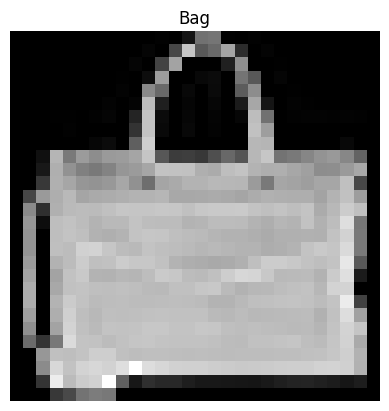

In [ ]:
#torch.manual_seed(42)
random_idx = torch.randint(0, len(train_feature_batch), size = [1]).item()
img, label = train_feature_batch[random_idx], train_labels_batch[random_idx]
plt.imshow(img.squeeze(), cmap = "gray")
plt.title(class_names[label])
plt.axis(False)
print(f"image size: {img.shape}")
print(f"label: {label}, label size:{label.shape}")

In [ ]:
#build a baseline model
#flatten layer ( width*height)
flatten_model = nn.Flatten()

#get a single sample
x= train_feature_batch[0]
output = flatten_model(x)
print(x.shape)
output.shape

torch.Size([1, 28, 28])


torch.Size([1, 784])

In [ ]:
from torch import nn
class FashionMNISTModelV0(nn.Module):
  def __init__(self,input_shape = int, output_shape = int, hidden_units = int):
    super().__init__()
    self.layer_stack = nn.Sequential(
        nn.Flatten(),
        nn.Linear(in_features = input_shape, out_features = hidden_units),
        nn.Linear(in_features = hidden_units, out_features= output_shape )
    )
  def forward(self, x):
    return self.layer_stack(x)

In [ ]:
torch.manual_seed(42)

#set up the model
model0 = FashionMNISTModelV0(
    input_shape = 784,
    hidden_units = 10,
    output_shape = len(class_names)
).to("cpu")


In [ ]:
#use dunny values
dummy_x= torch.rand([1, 1, 28,28])
model0(dummy_x)

tensor([[-0.0315,  0.3171,  0.0531, -0.2525,  0.5959,  0.2112,  0.3233,  0.2694,
         -0.1004,  0.0157]], grad_fn=<AddmmBackward0>)

In [ ]:
#model0.state_dict()

In [ ]:
#loss function, optimizer, evaluation metric
#import from helper functions
import requests
from pathlib import Path

if Path("helper_functions.py").is_file():
  print("helper functions already exists")
else :
  print("downloading helper functions")
  request = requests.get("https://raw.githubusercontent.com/mrdbourke/pytorch-deep-learning/refs/heads/main/helper_functions.py")
  with open("helper_functions.py", "wb") as f:
    f.write(request.content)


downloading helper functions


In [ ]:
#import accuracy metrics
from helper_functions import accuracy_fn
loss_fn = nn.CrossEntropyLoss()
optimizer = torch.optim.SGD(params = model0.parameters(), lr = 0.1)


In [ ]:
#create a funtion to time the experiments
from timeit import default_timer as timer
def print_train_time (start: float,
                      end: float,
                      device : torch.device = None) :

  total_time  = end-start
  print(f"Train_time on {device}: {total_time:.3f} seconds")
  return total_time

In [ ]:
from tqdm.auto import tqdm

torch.manual_seed(42)
train_time_start_on_cpu = timer()

epochs =3

for epoch in tqdm(range(epochs)):
  print(f"Epoch: {epoch}\n-----")
  #training
  train_loss = 0
  #loop through the training batches
  for batch, (x,y) in enumerate(train_dataloader):
    model0.train()
    #forward pass
    y_pred = model0(x)
    #calculate loss
    loss = loss_fn(y_pred, y)
    train_loss +=loss #accumulate train loss

    #optimizer zero grad
    optimizer.zero_grad()

    #loss backward
    loss.backward()

    #optimizer step
    optimizer.step()

    #print whats happening
    if batch % 400 == 0 :
      print(f"Looked at {batch*len(x)}/{len(train_dataloader.dataset)} samples")

  train_loss /= len(train_dataloader)

    #testing loop
  test_loss, test_acc = 0,0
  model0.eval()
  with torch.inference_mode():
    for x_test, y_test in test_dataloader:
        #forward pass
      test_pred =  model0(x_test)

         #loss
      test_loss += loss_fn(test_pred, y_test)

      #accuracy
      test_acc += accuracy_fn(y_true = y_test, y_pred = test_pred.argmax(dim=1))
    test_loss /= len(test_dataloader)
    test_acc /= len(test_dataloader)
  print(f"\nTrain loss: {train_loss:.4f} | Test loss: {test_loss:.4f}, test acc:{test_acc:.4f}")
  #calculate train time
  train_time_end_on_cpu = timer()
  total_train_time_on_cpu = print_train_time(start = train_time_start_on_cpu,
                                             end = train_time_end_on_cpu,
                                             device = str(next(model0.parameters()).device))



  0%|          | 0/3 [00:00<?, ?it/s]

Epoch: 0
-----
Looked at 0/60000 samples
Looked at 12800/60000 samples
Looked at 25600/60000 samples
Looked at 38400/60000 samples
Looked at 51200/60000 samples

Train loss: 0.5904 | Test loss: 0.5095, test acc:82.0387
Train_time on cpu: 9.334 seconds
Epoch: 1
-----
Looked at 0/60000 samples
Looked at 12800/60000 samples
Looked at 25600/60000 samples
Looked at 38400/60000 samples
Looked at 51200/60000 samples

Train loss: 0.4763 | Test loss: 0.4799, test acc:83.1969
Train_time on cpu: 18.416 seconds
Epoch: 2
-----
Looked at 0/60000 samples
Looked at 12800/60000 samples
Looked at 25600/60000 samples
Looked at 38400/60000 samples
Looked at 51200/60000 samples

Train loss: 0.4550 | Test loss: 0.4766, test acc:83.4265
Train_time on cpu: 27.748 seconds


In [ ]:
torch.manual_seed(42)
def eval_model (model : torch.nn.Module,
                data_loader : torch.utils.data.DataLoader,
                loss_fn : torch.nn.Module,
                accuracy_fn):
  loss, acc = 0,0
  model.eval()
  with torch.inference_mode():
    for x,y in data_loader:
      y_pred = model(x)

      loss += loss_fn(y_pred, y)
      acc += accuracy_fn(y_true = y, y_pred = y_pred.argmax(dim=1))
    loss /= len(data_loader)
    acc /= len(data_loader)

  return {"model_name": model.__class__.__name__,
          "model_loss": loss.item(),
          "model_acc": acc}
model0_results = eval_model(model = model0,
                            data_loader= test_dataloader,
                            loss_fn = loss_fn,
                            accuracy_fn= accuracy_fn)
model0_results

{'model_name': 'FashionMNISTModelV0',
 'model_loss': 0.47663888335227966,
 'model_acc': 83.42651757188499}

In [ ]:
#setup device agnostic code
torch.cuda.is_available()

True

In [ ]:
device = "cuda" if torch.cuda.is_available() else "cpu"
device

'cuda'

In [ ]:
from torch.nn.modules import ReLU
#non linearity relu model
#MODEL 1
class FashionMNISTModelV1(nn.Module):
  def __init__(self,input_shape = int, output_shape = int, hidden_units = int):
    super().__init__()
    self.layer_stack =  nn.Sequential(
        nn.Flatten(),
        nn.Linear(in_features = input_shape, out_features = hidden_units),
        nn.ReLU(),
        nn.Linear(in_features = hidden_units, out_features= output_shape ),
        nn.ReLU()
    )
  def forward(self, x : torch.Tensor):
    return self.layer_stack(x)



In [ ]:
torch.manual_seed(42)
model1 = FashionMNISTModelV1(input_shape = 784, #flattened output
                             hidden_units= 10,
                             output_shape = len(class_names)).to(device)

next(model1.parameters()).device


device(type='cuda', index=0)

In [ ]:
from helper_functions import accuracy_fn
loss_fn = nn.CrossEntropyLoss()
optimizer = torch.optim.SGD(params = model1.parameters(), lr = 0.1)

In [ ]:
#training and testing functions
def train_step(model: torch.nn.Module,
               data_loader : torch.utils.data.DataLoader,
               loss_fn: torch.nn.Module,
               optimizer : torch.optim.Optimizer,
               accuracy_fn,
               device : torch.device = device):
  train_loss, train_acc = 0, 0
  model.train()
  #loop through the training batches
  for batch, (x,y) in enumerate(data_loader):
    #putting data on target device
    x,y = x.to(device), y.to(device)

    #forward pass
    y_pred = model(x)
    #calculate loss
    loss = loss_fn(y_pred, y)
    train_loss +=loss #accumulate train loss
    train_acc += accuracy_fn(y_true = y, y_pred = y_pred.argmax(dim=1))
    #optimizer zero grad
    optimizer.zero_grad()

    #loss backward
    loss.backward()

    #optimizer step
    optimizer.step()

    #print whats happening
    if batch % 400 == 0 :
      print(f"Looked at {batch*len(x)}/{len(train_dataloader.dataset)} samples")
  #divide tptal loss and acc by lenght of train dataloader
  train_loss /= len(data_loader)
  train_acc /= len(data_loader)
  print(f"Train loss: {train_loss:.5f} | Train acc: {train_acc:.2f}")
  #return train_loss, train

In [ ]:
#test function
def test_step(model : torch.nn.Module,
              data_loader : torch.utils.data.DataLoader,
              loss_fn : torch.nn.Module,
              accuracy_fn,
              device : torch.device = device):


    #testing loop
  test_loss, test_acc = 0,0
  model.to(device)
  model.eval()
  with torch.inference_mode():
    for x, y in data_loader:
      x,y =x.to(device), y.to(device)
        #forward pass
      test_pred =  model(x)
         #loss
      test_loss += loss_fn(test_pred, y)

      #accuracy
      test_acc += accuracy_fn(y_true = y, y_pred = test_pred.argmax(dim=1))
    test_loss /= len(data_loader)
    test_acc /= len(data_loader)
  print(f"Test loss: {test_loss:.4f}, test acc:{test_acc:.4f}%\n")



In [ ]:
torch.manual_seed(42)

#measure time
from timeit import default_timer as timer
train_time_start_on_gpu = timer()

#set epoch
epochs = 3

#create optimizations and evaluation loop using the train and test functions
for epoch in tqdm(range(epochs)):
  print(f"Epoch: {epoch}\n-----")
  train_step (model = model1,
              data_loader = train_dataloader,
              accuracy_fn = accuracy_fn,
              loss_fn= loss_fn,
              optimizer = optimizer,
              device = device)
  test_step(model = model1,
            data_loader = test_dataloader,
            loss_fn = loss_fn,
            accuracy_fn = accuracy_fn,
            device = device)
train_time_end_on_gpu = timer()
total_train_time_on_cpu = print_train_time(start = train_time_start_on_cpu,
                                             end = train_time_end_on_cpu,
                                             device = str(next(model0.parameters()).device))

  0%|          | 0/3 [00:00<?, ?it/s]

Epoch: 0
-----
Looked at 0/60000 samples
Looked at 12800/60000 samples
Looked at 25600/60000 samples
Looked at 38400/60000 samples
Looked at 51200/60000 samples
Train loss: 1.09199 | Train acc: 61.34
Test loss: 0.9564, test acc:64.9960%

Epoch: 1
-----
Looked at 0/60000 samples
Looked at 12800/60000 samples
Looked at 25600/60000 samples
Looked at 38400/60000 samples
Looked at 51200/60000 samples
Train loss: 0.78101 | Train acc: 71.93
Test loss: 0.7223, test acc:73.9117%

Epoch: 2
-----
Looked at 0/60000 samples
Looked at 12800/60000 samples
Looked at 25600/60000 samples
Looked at 38400/60000 samples
Looked at 51200/60000 samples
Train loss: 0.67027 | Train acc: 75.94
Test loss: 0.6850, test acc:75.0200%

Train_time on cpu: 27.748 seconds


In [ ]:
model0_results

{'model_name': 'FashionMNISTModelV0',
 'model_loss': 0.47663888335227966,
 'model_acc': 83.42651757188499}

CONVOLUTIONAL NEURAL NETWORKS cnn explainer website

In [ ]:
#create a cnn
class FashionMNISTModelV2(nn.Module):
  def __init__(self, input_shape: int, hidden_units: int, output_shape: int):
    super().__init__()
    self.conv_block1 = nn.Sequential(
        nn.Conv2d(in_channels= input_shape,
                  out_channels= hidden_units,
                  kernel_size = 3,
                  stride = 1,
                  padding = 1),
        nn.ReLU(),
        nn.Conv2d(in_channels  = hidden_units,
                  out_channels = hidden_units,
                  kernel_size =3 ,
                  stride =1 ,
                  padding= 1),
        nn.ReLU(),
        nn.MaxPool2d(kernel_size = 2,
                     stride = 2)
    )
    self.conv_block2 = nn.Sequential(
        nn.Conv2d(in_channels = hidden_units,
                  out_channels = hidden_units,
                  kernel_size = 3,
                  stride =1,
                  padding = 1),
        nn.ReLU(),
        nn.Conv2d(in_channels = hidden_units,
                  out_channels = hidden_units,
                  kernel_size =3 ,
                  stride =1 ,
                  padding= 1),
        nn.MaxPool2d(kernel_size = 2,
                     stride = 2)
    )
    self.classifier = nn.Sequential(
        nn.Flatten(),
        nn.Linear(in_features = hidden_units*0,
                  out_features = output_shape)
        )
  def forward(self, x):
    x= self.conv_block1(x)
    print(x.shape)
    x= self.conv_block2(x)
    print(x.shape)
    x = self.classifier(x)
    return x


In [ ]:
torch.manual_seed(42)

# Create sample batch of random numbers with same size as image batch
images = torch.randn(size=(32, 3, 64, 64)) # [batch_size, color_channels, height, width]
test_image = images[0] # get a single image for testing
print(f"Image batch shape: {images.shape} -> [batch_size, color_channels, height, width]")
print(f"Single image shape: {test_image.shape} -> [color_channels, height, width]")
print(f"Single image pixel values:\n{test_image}")

Image batch shape: torch.Size([32, 3, 64, 64]) -> [batch_size, color_channels, height, width]
Single image shape: torch.Size([3, 64, 64]) -> [color_channels, height, width]
Single image pixel values:
tensor([[[ 1.9269,  1.4873,  0.9007,  ...,  1.8446, -1.1845,  1.3835],
         [ 1.4451,  0.8564,  2.2181,  ...,  0.3399,  0.7200,  0.4114],
         [ 1.9312,  1.0119, -1.4364,  ..., -0.5558,  0.7043,  0.7099],
         ...,
         [-0.5610, -0.4830,  0.4770,  ..., -0.2713, -0.9537, -0.6737],
         [ 0.3076, -0.1277,  0.0366,  ..., -2.0060,  0.2824, -0.8111],
         [-1.5486,  0.0485, -0.7712,  ..., -0.1403,  0.9416, -0.0118]],

        [[-0.5197,  1.8524,  1.8365,  ...,  0.8935, -1.5114, -0.8515],
         [ 2.0818,  1.0677, -1.4277,  ...,  1.6612, -2.6223, -0.4319],
         [-0.1010, -0.4388, -1.9775,  ...,  0.2106,  0.2536, -0.7318],
         ...,
         [ 0.2779,  0.7342, -0.3736,  ..., -0.4601,  0.1815,  0.1850],
         [ 0.7205, -0.2833,  0.0937,  ..., -0.1002, -2.3609,

In [ ]:
#nn.conv2d
conv_layer = nn.Conv2d(in_channels= 3,
                       out_channels = 10,
                       kernel_size = (3,3),
                       stride = 1,
                       padding = 0)
conv_output = conv_layer(test_image.unsqueeze())
conv_output

TypeError: unsqueeze() missing 1 required positional arguments: "dim"

In [ ]:
torch.manual_seed(42)
model2= FashionMNISTModelV2(input_shape= 1,
                            hidden_units= 10,
                            output_shape = len(class_names)).to(device)